In [4]:
import sys
from pathlib import Path

# Go TWO levels up → project root
PROJECT_ROOT = Path("../../").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Added to sys.path:", PROJECT_ROOT)

Added to sys.path: /home/twilightpriest/GitHub/reflect-aug-seg


In [5]:
import os
print(os.listdir(PROJECT_ROOT))

['LICENSE', 'requirements.txt', 'reports', '.gitignore', 'data', 'notebooks', '.gitattributes', 'artifacts', 'configs', 'final_pipeline', '.git', 'src', 'tests', '.venv', 'scripts', 'results', 'README.md']


In [6]:
from pathlib import Path
from src.io.loader import load_frame

SEQ_PATH = Path("../../data/semantickitti/dataset/sequences/00")

frame = load_frame(SEQ_PATH, "000000")

print("XYZ shape:", frame["xyz"].shape)
print("Intensity shape:", frame["intensity"].shape)
print("Semantic shape:", frame["semantic_labels"].shape)

XYZ shape: (124668, 3)
Intensity shape: (124668,)
Semantic shape: (124668,)


In [11]:
import importlib
import src.io.sequence_sampler as sampler

importlib.reload(sampler)

from src.io.sequence_sampler import sample_contiguous_window

print("Module reloaded ✅")

Module reloaded ✅


In [12]:
# --- Imports ---
import sys
from pathlib import Path

# --- Fix import path ---
PROJECT_ROOT = Path("../../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# --- Import sampler ---
from src.io.sequence_sampler import sample_contiguous_window

# --- Dataset ---
DATASET_ROOT = Path("../../data/semantickitti/dataset")

# =========================================================
# ⚙️ CONFIG (final form)
# =========================================================

FPS = 10
DURATION = 60
WINDOW_SIZE = FPS * DURATION

ALLOWED_SEQUENCES = ["00", "01", "02"]

# =========================================================
# 🧪 Run sampler
# =========================================================

seq_id, frames = sample_contiguous_window(
    DATASET_ROOT,
    window_size=WINDOW_SIZE,
    allowed_sequences=ALLOWED_SEQUENCES
)

# =========================================================
# 📊 Debug
# =========================================================

print("Selected sequence:", seq_id)
print("Frame count:", len(frames))
print("First frame:", frames[0])
print("Last frame:", frames[-1])

# --- Continuity check ---
frame_numbers = [int(f) for f in frames]
diffs = [j - i for i, j in zip(frame_numbers[:-1], frame_numbers[1:])]

print("\nContinuity check (first 10):", diffs[:10])

# --- Assertions ---
assert len(frames) == WINDOW_SIZE, "Window size mismatch!"
assert all(d == 1 for d in diffs), "Frames are not continuous!"
assert seq_id in ALLOWED_SEQUENCES, "Invalid sequence selected!"

print("\n✅ Sampling pipeline fully correct")

Selected sequence: 01
Frame count: 600
First frame: 000230
Last frame: 000829

Continuity check (first 10): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

✅ Sampling pipeline fully correct


In [13]:
# --- Reload module (important during dev) ---
import importlib
import src.signals.reflectivity as refl

importlib.reload(refl)

from src.io.loader import load_frame
from src.signals.reflectivity import compute_signals

# --- Load ONE frame ---
from pathlib import Path
SEQ_PATH = Path("../../data/semantickitti/dataset/sequences/00")

frame = load_frame(SEQ_PATH, "000000")

# --- Compute signals ---
frame_sig = compute_signals(frame)

# --- Debug ---
print("Ranges shape:", frame_sig["ranges"].shape)
print("Pseudo-reflectivity shape:", frame_sig["pseudo_reflectivity"].shape)

print("\nRange stats:")
print(" min:", frame_sig["ranges"].min())
print(" max:", frame_sig["ranges"].max())
print(" mean:", frame_sig["ranges"].mean())

print("\nPseudo-reflectivity stats:")
print(" min:", frame_sig["pseudo_reflectivity"].min())
print(" max:", frame_sig["pseudo_reflectivity"].max())
print(" mean:", frame_sig["pseudo_reflectivity"].mean())

# sanity
assert frame_sig["ranges"].shape == frame_sig["intensity"].shape
assert frame_sig["pseudo_reflectivity"].shape == frame_sig["intensity"].shape

print("\n✅ Signal computation correct")

Ranges shape: (124668,)
Pseudo-reflectivity shape: (124668,)

Range stats:
 min: 1.3483586
 max: 79.73653
 mean: 13.565046

Pseudo-reflectivity stats:
 min: 0.0
 max: 58.805172
 mean: 3.6286917

✅ Signal computation correct


In [14]:
# --- Reload ---
import importlib
import src.semantics.class_stats as cs

importlib.reload(cs)

from src.io.loader import load_frame
from src.semantics.class_stats import compute_class_percentages, get_top_k_classes

from pathlib import Path

SEQ_PATH = Path("../../data/semantickitti/dataset/sequences/00")

frame = load_frame(SEQ_PATH, "000000")

# --- Compute stats ---
class_pct = compute_class_percentages(frame["semantic_labels"])

top_classes = get_top_k_classes(
    class_pct,
    k=5,
    ignore_classes={0, 255}   # ignore unlabeled
)

# --- Debug ---
print("Top 5 classes (class_id, percentage):")
for cls, pct in top_classes:
    print(f"Class {cls}: {pct*100:.2f}%")

print("\nTotal classes found:", len(class_pct))

# sanity
assert abs(sum(class_pct.values()) - 1.0) < 1e-6

print("\n✅ Semantic stats correct")

Top 5 classes (class_id, percentage):
Class 40: 27.46%
Class 70: 21.76%
Class 48: 21.14%
Class 50: 14.65%
Class 10: 3.40%

Total classes found: 17

✅ Semantic stats correct


In [15]:
# --- Reload ---
import importlib
import src.semantics.class_stats as cs
import src.semantics.label_map as lm

importlib.reload(cs)
importlib.reload(lm)

from src.io.loader import load_frame
from src.semantics.class_stats import compute_class_percentages, get_top_k_classes
from src.semantics.label_map import get_class_name

from pathlib import Path

SEQ_PATH = Path("../../data/semantickitti/dataset/sequences/00")

frame = load_frame(SEQ_PATH, "000000")

# --- Compute ---
class_pct = compute_class_percentages(frame["semantic_labels"])

top_classes = get_top_k_classes(
    class_pct,
    k=5,
    ignore_classes={0, 255}
)

# --- Pretty print ---
print("Top 5 classes (name, percentage):")
for cls, pct in top_classes:
    name = get_class_name(cls)
    print(f"{name}: {pct*100:.2f}%")

print("\n✅ Label mapping working")

Top 5 classes (name, percentage):
road: 27.46%
vegetation: 21.76%
sidewalk: 21.14%
building: 14.65%
car: 3.40%

✅ Label mapping working


Sequence: 00
Frame: 000139


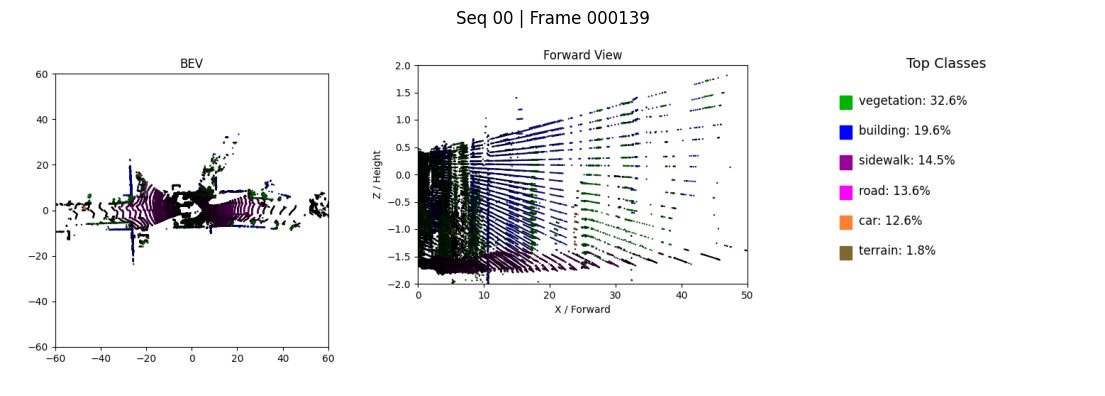

In [23]:
import importlib
import src.visualization.frame_renderer as fr
importlib.reload(fr)

from pathlib import Path
from src.io.sequence_sampler import sample_contiguous_window
from src.io.loader import load_frame
from src.signals.reflectivity import compute_signals
from src.visualization.frame_renderer import render_frame

import matplotlib.pyplot as plt

DATASET_ROOT = Path("../../data/semantickitti/dataset")

# ✅ RANDOM + CONTINUOUS
seq_id, frames = sample_contiguous_window(
    DATASET_ROOT,
    window_size=1,
    allowed_sequences=["00", "01", "02"]
)

frame_id = frames[0]

print("Sequence:", seq_id)
print("Frame:", frame_id)

SEQ_PATH = DATASET_ROOT / "sequences" / seq_id

frame = load_frame(SEQ_PATH, frame_id)
frame = compute_signals(frame)

img = render_frame(frame)

plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Seq {seq_id} | Frame {frame_id}")
plt.show()

In [24]:
import time
from pathlib import Path

from src.io.sequence_sampler import sample_contiguous_window
from src.io.loader import load_frame
from src.signals.reflectivity import compute_signals
from src.visualization.frame_renderer import render_frame
from src.animation.gif_writer import save_gif

DATASET_ROOT = Path("../../data/semantickitti/dataset")

# =========================================================
# ⚙️ FINAL CONFIG
# =========================================================

FPS = 10
DURATION = 60
WINDOW = FPS * DURATION   # 600 frames

ALLOWED_SEQUENCES = ["00", "01", "02"]

# =========================================================
# 🎯 SAMPLE SEQUENCE
# =========================================================

seq_id, frame_ids = sample_contiguous_window(
    DATASET_ROOT,
    window_size=WINDOW,
    allowed_sequences=ALLOWED_SEQUENCES
)

SEQ_PATH = DATASET_ROOT / "sequences" / seq_id

print(f"\n🚀 Running sequence {seq_id} with {WINDOW} frames\n")

# =========================================================
# 🎬 RENDER LOOP
# =========================================================

frames = []
start_time = time.time()

for i, fid in enumerate(frame_ids):

    # --- progress ---
    if i % 20 == 0:
        elapsed = time.time() - start_time
        print(f"[{i}/{WINDOW}] | {elapsed:.1f}s")

    # --- pipeline ---
    frame = load_frame(SEQ_PATH, fid)
    frame = compute_signals(frame)

    img = render_frame(frame)
    frames.append(img)

# =========================================================
# 💾 SAVE
# =========================================================

output_path = f"final_seq_{seq_id}_60s.gif"

save_gif(frames, output_path, fps=FPS)

total_time = time.time() - start_time

print("\n✅ DONE")
print("Saved:", output_path)
print(f"Total time: {total_time/60:.2f} min")


🚀 Running sequence 01 with 600 frames

[0/600] | 0.0s
[20/600] | 20.5s
[40/600] | 41.1s
[60/600] | 61.4s
[80/600] | 82.9s
[100/600] | 102.9s
[120/600] | 123.1s
[140/600] | 144.0s
[160/600] | 165.9s
[180/600] | 187.3s
[200/600] | 209.6s
[220/600] | 232.0s
[240/600] | 254.6s
[260/600] | 278.5s
[280/600] | 302.8s
[300/600] | 329.1s
[320/600] | 354.1s
[340/600] | 379.1s
[360/600] | 404.2s
[380/600] | 429.5s
[400/600] | 452.1s
[420/600] | 474.7s
[440/600] | 495.4s
[460/600] | 515.5s
[480/600] | 535.6s
[500/600] | 555.9s
[520/600] | 577.4s
[540/600] | 599.6s
[560/600] | 622.8s
[580/600] | 648.0s

✅ DONE
Saved: final_seq_01_60s.gif
Total time: 11.86 min
